# CheXpert Data Exploration

Exploratory analysis of the processed Parquet manifests generated by `etl.py`.

**Manifests:**
- `src/data/train_manifest.parquet`
- `src/data/valid_manifest.parquet`

In [25]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

_cwd = Path().resolve()
REPO_ROOT = next(
    (p for p in [_cwd, *_cwd.parents] if (p / 'pyproject.toml').exists()),
    _cwd
)

SRC_DATA      = REPO_ROOT / 'src' / 'data'
IMG_ROOT      = REPO_ROOT / 'src' / 'data' / '1'
TRAIN_PARQUET = SRC_DATA / 'train_manifest.parquet'
VALID_PARQUET = SRC_DATA / 'valid_manifest.parquet'
TEST_PARQUET  = SRC_DATA / 'test_manifest.parquet'

print('Repo root     :', REPO_ROOT)
print('Train parquet :', TRAIN_PARQUET, '| exists:', TRAIN_PARQUET.exists())
print('Valid parquet :', VALID_PARQUET, '| exists:', VALID_PARQUET.exists())
print('Test parquet  :', TEST_PARQUET,  '| exists:', TEST_PARQUET.exists())
print('Polars version:', pl.__version__)


Repo root     : C:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis
Train parquet : C:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\src\data\train_manifest.parquet | exists: True
Valid parquet : C:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\src\data\valid_manifest.parquet | exists: True
Test parquet  : C:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\src\data\test_manifest.parquet | exists: True
Polars version: 1.40.0


## 1. Load Manifests

In [26]:
train_df = pl.read_parquet(TRAIN_PARQUET)
valid_df = pl.read_parquet(VALID_PARQUET)
test_df  = pl.read_parquet(TEST_PARQUET)

print(f'Train shape : {train_df.shape}')
print(f'Valid shape : {valid_df.shape}')
print(f'Test shape  : {test_df.shape}')


Train shape : (185452, 33)
Valid shape : (5575, 33)
Test shape  : (202, 33)


## 2. Schema & Column Inventory

In [27]:
print('=== TRAIN SCHEMA ===')
for name, dtype in train_df.schema.items():
    print(f'  {name:<45} {dtype}')

=== TRAIN SCHEMA ===
  Path                                          String
  Sex                                           String
  Age                                           Int64
  Frontal/Lateral                               String
  AP/PA                                         String
  No Finding                                    Int8
  Enlarged Cardiomediastinum                    Int8
  Cardiomegaly                                  Int8
  Lung Opacity                                  Int8
  Lung Lesion                                   Int8
  Edema                                         Int8
  Consolidation                                 Int8
  Pneumonia                                     Int8
  Atelectasis                                   Int8
  Pneumothorax                                  Int8
  Pleural Effusion                              Int8
  Pleural Other                                 Int8
  Fracture                                      Int8
  Support Device

In [28]:
train_df.head(5)

Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding_uncertain,Enlarged Cardiomediastinum_uncertain,Cardiomegaly_uncertain,Lung Opacity_uncertain,Lung Lesion_uncertain,Edema_uncertain,Consolidation_uncertain,Pneumonia_uncertain,Atelectasis_uncertain,Pneumothorax_uncertain,Pleural Effusion_uncertain,Pleural Other_uncertain,Fracture_uncertain,Support Devices_uncertain
str,str,i64,str,str,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
"""CheXpert-v1.0-small/train/pati…","""Female""",68,"""Frontal""","""AP""",1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""CheXpert-v1.0-small/train/pati…","""Female""",87,"""Frontal""","""AP""",0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,1,0,1,0,0,0
"""CheXpert-v1.0-small/train/pati…","""Female""",83,"""Frontal""","""AP""",0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
"""CheXpert-v1.0-small/train/pati…","""Male""",41,"""Frontal""","""AP""",0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""CheXpert-v1.0-small/train/pati…","""Female""",20,"""Frontal""","""PA""",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [29]:
# Separate label columns from uncertainty-tracking columns
LABEL_COLS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]
UNCERTAIN_COLS = [c for c in train_df.columns if c.endswith('_uncertain')]

print(f'Label columns    : {len(LABEL_COLS)}')
print(f'Uncertain columns: {len(UNCERTAIN_COLS)}')
print(f'Other columns    : {[c for c in train_df.columns if c not in LABEL_COLS and c not in UNCERTAIN_COLS]}')

Label columns    : 14
Uncertain columns: 14
Other columns    : ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA']


## 3. Basic Statistics

In [30]:
# Null / missing check
null_counts = train_df.null_count()
print('Null counts in train manifest:')
print(null_counts)

Null counts in train manifest:
shape: (1, 33)
┌──────┬─────┬─────┬───────────────┬───┬──────────────┬──────────────┬──────────────┬──────────────┐
│ Path ┆ Sex ┆ Age ┆ Frontal/Later ┆ … ┆ Pleural Effu ┆ Pleural Othe ┆ Fracture_unc ┆ Support Devi │
│ ---  ┆ --- ┆ --- ┆ al            ┆   ┆ sion_uncerta ┆ r_uncertain  ┆ ertain       ┆ ces_uncertai │
│ u32  ┆ u32 ┆ u32 ┆ ---           ┆   ┆ in           ┆ ---          ┆ ---          ┆ n            │
│      ┆     ┆     ┆ u32           ┆   ┆ ---          ┆ u32          ┆ u32          ┆ ---          │
│      ┆     ┆     ┆               ┆   ┆ u32          ┆              ┆              ┆ u32          │
╞══════╪═════╪═════╪═══════════════╪═══╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 0    ┆ 0   ┆ 0   ┆ 0             ┆ … ┆ 0            ┆ 0            ┆ 0            ┆ 0            │
└──────┴─────┴─────┴───────────────┴───┴──────────────┴──────────────┴──────────────┴──────────────┘


In [31]:
# Descriptive stats for label columns
train_df.select(LABEL_COLS).describe()

statistic,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",185452.0,185452.0,185452.0,185452.0,185452.0,185452.0,185452.0,185452.0,185452.0,185452.0,185452.0,185452.0,185452.0,185452.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.088611,0.048185,0.122878,0.493281,0.036775,0.260774,0.068007,0.024314,0.155733,0.092277,0.402525,0.013049,0.039094,0.561089
"""std""",0.284182,0.214157,0.328298,0.499956,0.188209,0.439058,0.251758,0.154021,0.362603,0.289418,0.490408,0.113486,0.193818,0.496255
"""min""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
"""75%""",0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
"""max""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 4. Label Prevalence (Positive Rate per Pathology)

In [32]:
def label_prevalence(df: pl.DataFrame, label_cols: list[str]) -> pd.DataFrame:
    n = len(df)
    stats = []
    for col in label_cols:
        if col not in df.columns:
            continue
        pos = df[col].sum()
        stats.append({'label': col, 'positive': pos, 'pct': round(100 * pos / n, 2)})
    return pd.DataFrame(stats).sort_values('pct', ascending=False).reset_index(drop=True)

train_prev = label_prevalence(train_df, LABEL_COLS)
valid_prev = label_prevalence(valid_df, LABEL_COLS)
test_prev  = label_prevalence(test_df,  LABEL_COLS)

print('=== TRAIN prevalence ===')
print(train_prev.to_string(index=False))
print('\n=== TEST prevalence ===')
print(test_prev.to_string(index=False))


=== TRAIN prevalence ===
                     label  positive   pct
           Support Devices    104055 56.11
              Lung Opacity     91480 49.33
          Pleural Effusion     74649 40.25
                     Edema     48361 26.08
               Atelectasis     28881 15.57
              Cardiomegaly     22788 12.29
              Pneumothorax     17113  9.23
                No Finding     16433  8.86
             Consolidation     12612  6.80
Enlarged Cardiomediastinum      8936  4.82
                  Fracture      7250  3.91
               Lung Lesion      6820  3.68
                 Pneumonia      4509  2.43
             Pleural Other      2420  1.30

=== TEST prevalence ===
                     label  positive   pct
              Lung Opacity       117 57.92
Enlarged Cardiomediastinum       105 51.98
           Support Devices        99 49.01
               Atelectasis        75 37.13
              Cardiomegaly        66 32.67
          Pleural Effusion        64 31.68
    

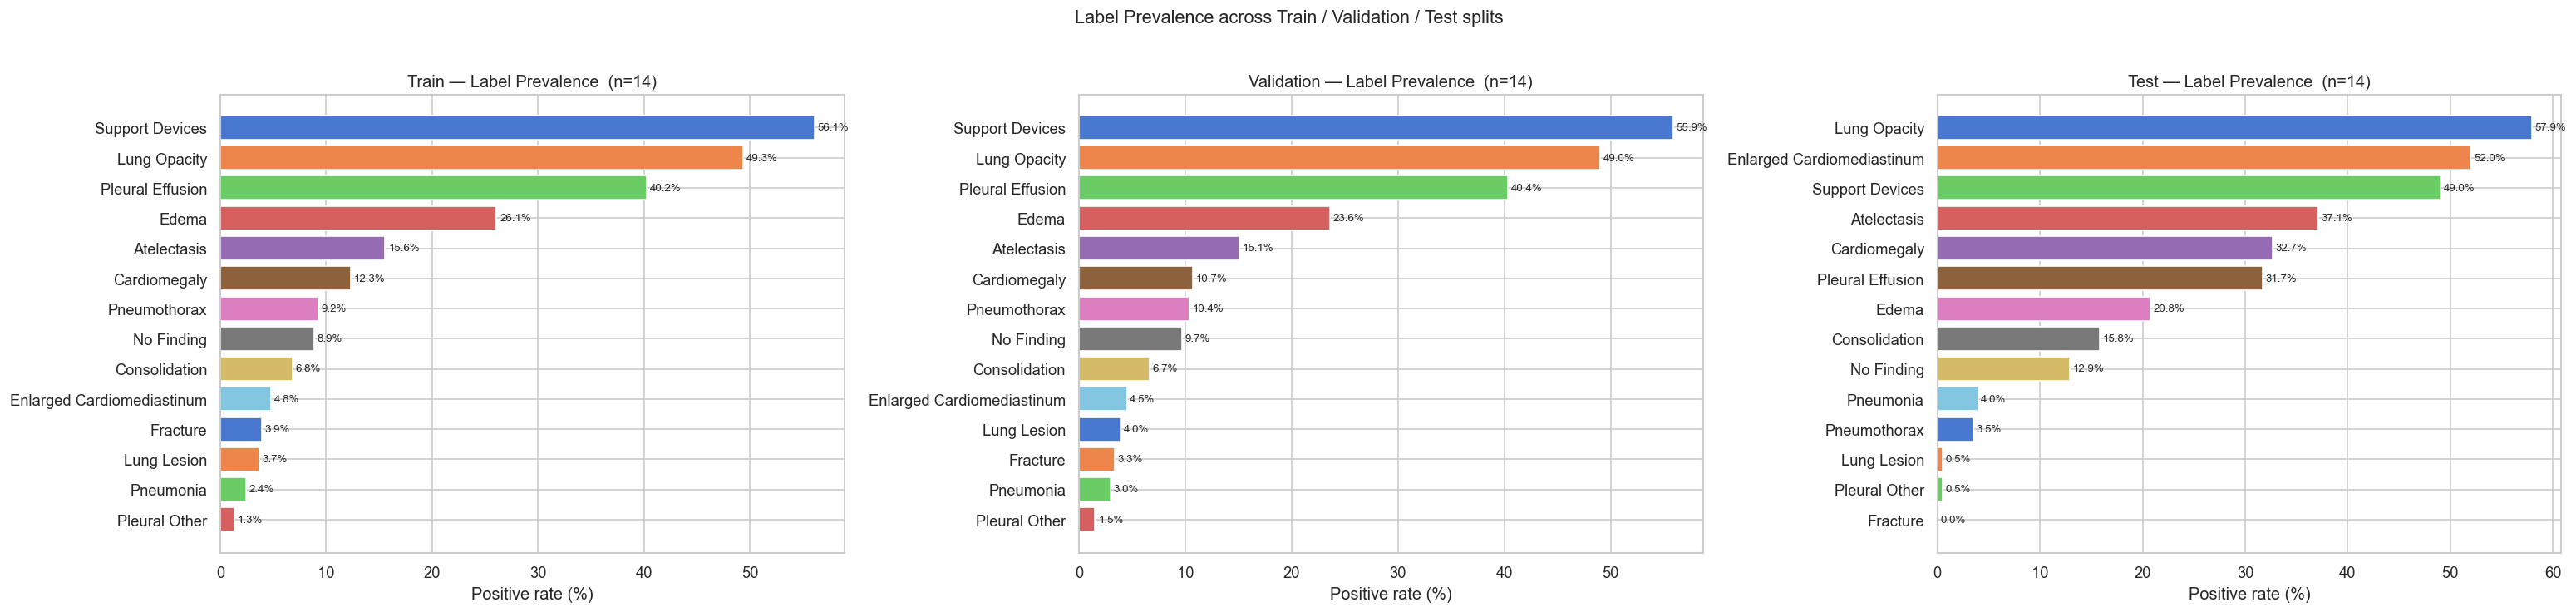

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(26, 6), sharey=False)

for ax, prev, title in zip(axes,
                            [train_prev, valid_prev, test_prev],
                            ['Train', 'Validation', 'Test']):
    bars = ax.barh(prev['label'], prev['pct'], color=sns.color_palette('muted', len(prev)))
    ax.set_xlabel('Positive rate (%)')
    ax.set_title(f'{title} — Label Prevalence  (n={len(prev)})')
    ax.invert_yaxis()
    for bar, val in zip(bars, prev['pct']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle('Label Prevalence across Train / Validation / Test splits', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4b. Positive Label Counts — Justification for 5-Label Focus

The CheXpert competition (and the example repo) trained on only **5 pathologies**:
`Cardiomegaly`, `Edema`, `Consolidation`, `Atelectasis`, `Pleural Effusion`.

The chart below shows raw positive-label counts (`label == 1`) for all **12 clinical labels**
(excluding `No Finding` and `Support Devices`).
The 5 competition labels are highlighted in orange; the remaining 7 are shown in steel-blue.

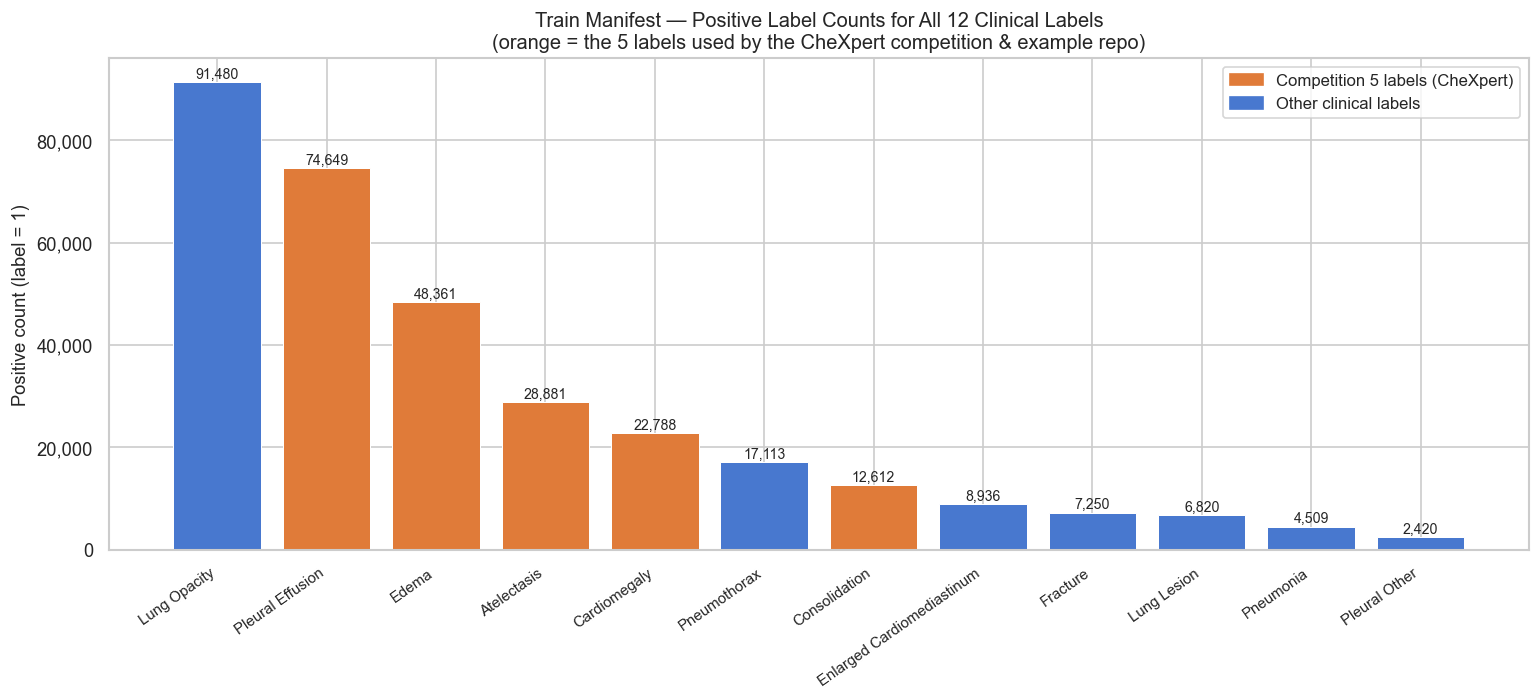

Competition-5 positive labels : 187,291  (57.5% of all 12-label positives)
Remaining 7 labels            : 138,528  (42.5%)

Per-label counts (sorted):
  Lung Opacity                         91,480
  Pleural Effusion                     74,649 ★
  Edema                                48,361 ★
  Atelectasis                          28,881 ★
  Cardiomegaly                         22,788 ★
  Pneumothorax                         17,113
  Consolidation                        12,612 ★
  Enlarged Cardiomediastinum            8,936
  Fracture                              7,250
  Lung Lesion                           6,820
  Pneumonia                             4,509
  Pleural Other                         2,420


In [34]:
COMPETITION_5 = {
    'Cardiomegaly', 'Edema', 'Consolidation', 'Atelectasis', 'Pleural Effusion'
}

# 12 clinical labels — drop 'No Finding' and 'Support Devices'
CLINICAL_12 = [
    'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion',
    'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture',
]

# Raw positive counts from the train manifest
pos_counts = {col: int(train_df[col].sum()) for col in CLINICAL_12 if col in train_df.columns}
labels_sorted = sorted(pos_counts, key=pos_counts.get, reverse=True)
counts_sorted = [pos_counts[l] for l in labels_sorted]
colors = ['#E07B39' if l in COMPETITION_5 else '#4878CF' for l in labels_sorted]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(labels_sorted, counts_sorted, color=colors, edgecolor='white', linewidth=0.6)

# Annotate bar tops
for bar, val in zip(bars, counts_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=8.5)

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#E07B39', label='Competition 5 labels (CheXpert)'),
    Patch(color='#4878CF', label='Other clinical labels'),
]
ax.legend(handles=legend_handles, fontsize=10)

ax.set_ylabel('Positive count (label = 1)', fontsize=11)
ax.set_title('Train Manifest — Positive Label Counts for All 12 Clinical Labels\n'
             '(orange = the 5 labels used by the CheXpert competition & example repo)',
             fontsize=12)
ax.set_xticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# Print the ratio: competition-5 total vs all-12 total
comp5_total = sum(pos_counts[l] for l in COMPETITION_5 if l in pos_counts)
all12_total = sum(counts_sorted)
print(f"Competition-5 positive labels : {comp5_total:,}  ({100*comp5_total/all12_total:.1f}% of all 12-label positives)")
print(f"Remaining 7 labels            : {all12_total - comp5_total:,}  ({100*(all12_total-comp5_total)/all12_total:.1f}%)")
print()
print("Per-label counts (sorted):")
for l in labels_sorted:
    star = " ★" if l in COMPETITION_5 else ""
    print(f"  {l:<35} {pos_counts[l]:>7,}{star}")

## 5. Uncertainty Rate per Label

The ETL tracks which original values were `-1` (uncertain) before U-Zero policy was applied.

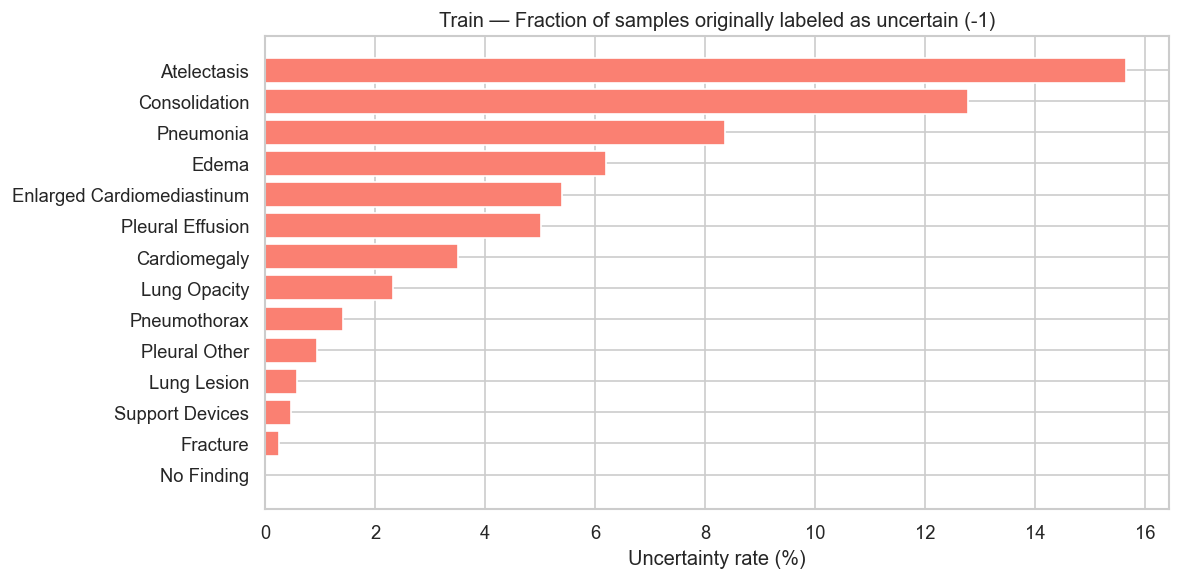

                     label  n_uncertain   pct
               Atelectasis        29015 15.65
             Consolidation        23717 12.79
                 Pneumonia        15522  8.37
                     Edema        11501  6.20
Enlarged Cardiomediastinum         9993  5.39
          Pleural Effusion         9297  5.01
              Cardiomegaly         6490  3.50
              Lung Opacity         4300  2.32
              Pneumothorax         2629  1.42
             Pleural Other         1748  0.94
               Lung Lesion         1074  0.58
           Support Devices          894  0.48
                  Fracture          486  0.26
                No Finding            0  0.00


In [35]:
n_train = len(train_df)
uncertain_stats = []
for ucol in UNCERTAIN_COLS:
    if ucol in train_df.columns:
        n_uncertain = train_df[ucol].sum()
        uncertain_stats.append({'label': ucol.replace('_uncertain', ''), 'n_uncertain': n_uncertain,
                                 'pct': round(100 * n_uncertain / n_train, 2)})

uncertain_df = pd.DataFrame(uncertain_stats).sort_values('pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(uncertain_df['label'], uncertain_df['pct'], color='salmon')
ax.set_xlabel('Uncertainty rate (%)')
ax.set_title('Train — Fraction of samples originally labeled as uncertain (-1)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(uncertain_df.to_string(index=False))

## 6. Multi-label Co-occurrence (Label Correlation)

In [36]:
label_pdf = train_df.select(LABEL_COLS).to_pandas().astype(float)
corr = label_pdf.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Label Correlation Matrix (Train)')
plt.tight_layout()
plt.show()

ModuleNotFoundError: pa.Table requires 'pyarrow' module to be installed

## 7. Labels-per-image Distribution

How many positive labels does each radiograph have?

In [ ]:
label_sum = train_df.select(LABEL_COLS).to_pandas().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = label_sum.value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color=sns.color_palette('muted')[0])
axes[0].set_xlabel('Number of positive labels')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Train — Labels per image (count)')

axes[1].bar(counts.index.astype(str), 100 * counts.values / len(label_sum),
            color=sns.color_palette('muted')[1])
axes[1].set_xlabel('Number of positive labels')
axes[1].set_ylabel('Percentage of images (%)')
axes[1].set_title('Train — Labels per image (%)')

plt.tight_layout()
plt.show()

print(f'Mean labels per image : {label_sum.mean():.3f}')
print(f'Median                : {label_sum.median():.1f}')
print(f'Images with 0 labels  : {(label_sum == 0).sum()} ({100*(label_sum==0).mean():.1f}%)')

## 8. Patient & Study Statistics

In [ ]:
# Extract patient ID from Path column  (e.g. '...train/patient00001/study1/view1_frontal.jpg')
train_with_meta = train_df.with_columns([
    pl.col('Path').str.extract(r'(patient\d+)', 1).alias('patient_id'),
    pl.col('Path').str.extract(r'(study\d+)', 1).alias('study_id'),
])

n_patients = train_with_meta['patient_id'].n_unique()
n_studies  = train_with_meta.select(['patient_id', 'study_id']).unique().shape[0]
n_images   = len(train_df)

print(f'Unique patients : {n_patients:,}')
print(f'Unique studies  : {n_studies:,}')
print(f'Total images    : {n_images:,}')
print(f'Avg studies/patient : {n_studies/n_patients:.2f}')
print(f'Avg images/patient  : {n_images/n_patients:.2f}')

In [ ]:
# Images per patient distribution
imgs_per_patient = (
    train_with_meta
    .group_by('patient_id')
    .agg(pl.count().alias('n_images'))
    .sort('n_images', descending=True)
)

fig, ax = plt.subplots(figsize=(10, 4))
vals = imgs_per_patient['n_images'].to_numpy()
ax.hist(vals, bins=40, edgecolor='white', color=sns.color_palette('muted')[2])
ax.set_xlabel('Images per patient')
ax.set_ylabel('Number of patients')
ax.set_title('Train — Images per patient distribution')
ax.axvline(np.median(vals), color='red', linestyle='--', label=f'Median = {np.median(vals):.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print('Top-10 patients by image count:')
print(imgs_per_patient.head(10))

## 9. Train vs Validation Comparison

In [ ]:
merged = (
    train_prev
    .merge(valid_prev, on='label', suffixes=('_train', '_valid'))
    .merge(test_prev[['label', 'pct']].rename(columns={'pct': 'pct_test'}), on='label')
)

x = np.arange(len(merged))
w = 0.25

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w,   merged['pct_train'], w, label='Train',      color=sns.color_palette('muted')[0])
ax.bar(x,       merged['pct_valid'], w, label='Validation',  color=sns.color_palette('muted')[1])
ax.bar(x + w,   merged['pct_test'],  w, label='Test',        color=sns.color_palette('muted')[2])
ax.set_xticks(x)
ax.set_xticklabels(merged['label'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Positive rate (%)')
ax.set_title('Label Prevalence: Train vs Validation vs Test')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Sample Image Viewer

Display a few radiographs with their labels.

In [ ]:
def get_positive_labels(row: dict, label_cols: list[str]) -> list[str]:
    return [l for l in label_cols if row.get(l, 0) == 1]

def show_samples(df: pl.DataFrame, img_root: Path, label_cols: list[str],
                 n: int = 6, seed: int = 42):
    sample = df.sample(n=n, seed=seed).to_dicts()
    
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    axes = axes.flatten()
    
    for i, record in enumerate(sample):
        rel_path = record['Path']
        img_path = img_root / rel_path
        try:
            img = Image.open(img_path).convert('RGB')
            axes[i].imshow(img, cmap='gray')
        except FileNotFoundError:
            axes[i].text(0.5, 0.5, f'Not found:\n{rel_path}',
                         ha='center', va='center', transform=axes[i].transAxes, fontsize=7)
            axes[i].set_facecolor('#eee')
        
        pos_labels = get_positive_labels(record, label_cols)
        title = ', '.join(pos_labels) if pos_labels else 'No Finding'
        axes[i].set_title(title, fontsize=8, wrap=True)
        axes[i].axis('off')
    
    # hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle('Random Training Samples', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

show_samples(train_df, IMG_ROOT, LABEL_COLS, n=6)

## 11. Class Imbalance Summary

Compute positive-to-negative ratio — useful for deciding loss weighting.

In [ ]:
n = len(train_df)
imbalance = []
for col in LABEL_COLS:
    if col not in train_df.columns:
        continue
    pos = int(train_df[col].sum())
    neg = n - pos
    ratio = neg / pos if pos > 0 else float('inf')
    pos_weight = neg / pos if pos > 0 else 0.0   # BCEWithLogitsLoss pos_weight
    imbalance.append({'label': col, 'positive': pos, 'negative': neg,
                      'neg:pos ratio': round(ratio, 1), 'pos_weight': round(pos_weight, 2)})

imb_df = pd.DataFrame(imbalance).sort_values('neg:pos ratio', ascending=False)
print(imb_df.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#d62728' if r > 20 else '#1f77b4' for r in imb_df['neg:pos ratio']]
ax.bar(imb_df['label'], imb_df['neg:pos ratio'], color=colors)
ax.axhline(10, color='orange', linestyle='--', linewidth=1, label='10:1 threshold')
ax.set_xticklabels(imb_df['label'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Negative : Positive ratio')
ax.set_title('Class Imbalance (Train) — red bars exceed 20:1')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Parquet File Info

In [ ]:
import os
for path, name in [(TRAIN_PARQUET, 'train'), (VALID_PARQUET, 'valid')]:
    size_mb = os.path.getsize(path) / 1e6
    df = train_df if name == 'train' else valid_df
    print(f'{name}_manifest.parquet')
    print(f'  File size : {size_mb:.2f} MB')
    print(f'  Rows      : {df.shape[0]:,}')
    print(f'  Columns   : {df.shape[1]}')
    print()

---
## 13. Uncertainty Rate per Label — Detailed View
> How often each label was originally `-1` (uncertain) before U-Zero policy set it to 0.

In [ ]:
n = len(train_df)
uncertain_stats = [
    {'label': c.replace('_uncertain', ''), 'pct': 100 * train_df[c].sum() / n}
    for c in UNCERTAIN_COLS if c in train_df.columns
]
uncertain_stats.sort(key=lambda x: -x['pct'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([d['label'] for d in uncertain_stats], [d['pct'] for d in uncertain_stats], color='salmon')
ax.set_xlabel('Uncertainty rate (%)')
ax.set_title('Train — Fraction of samples originally labelled as uncertain (-1)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

for d in uncertain_stats:
    print(f"  {d['label']:<35} {d['pct']:>6.2f}%")

---
## 14. Positive-Weight Table for BCEWithLogitsLoss
> The `pos_weight` value for each label is `neg / pos`. Pass these to `BCEWithLogitsLoss(pos_weight=...)` to counteract class imbalance during training.

In [ ]:
n = len(train_df)

print(f"{'Label':<35} {'Pos':>8} {'Neg':>8} {'Neg:Pos':>10} {'pos_weight':>12}")
print('-' * 78)
for col in CLINICAL_12:
    if col not in train_df.columns:
        continue
    pos = int(train_df[col].sum())
    neg = n - pos
    ratio = neg / pos if pos > 0 else float('inf')
    print(f"{col:<35} {pos:>8,} {neg:>8,} {ratio:>10.1f} {ratio:>12.2f}")

---
## 15. Train vs Validation Distribution Test (Chi-Square)
> Statistically tests whether each label's positive rate is consistent across the train and validation splits. A `p-value > 0.05` means the split is consistent.

In [ ]:
from scipy.stats import chi2_contingency

print(f"{'Label':<35} {'chi2':>8} {'p-value':>10} {'Consistent?':>12}")
print('-' * 70)
for col in CLINICAL_12:
    if col not in train_df.columns or col not in valid_df.columns:
        continue
    train_pos = int(train_df[col].sum())
    valid_pos = int(valid_df[col].sum())
    contingency = [[train_pos, len(train_df) - train_pos],
                   [valid_pos, len(valid_df) - valid_pos]]
    chi2, p, *_ = chi2_contingency(contingency)
    flag = 'YES' if p > 0.05 else 'NO  <--'
    print(f"{col:<35} {chi2:>8.2f} {p:>10.4f} {flag:>12}")